# 🌍 What Drives GDP Growth? A Cross-Country Macroeconomic Analysis

## 🎯 Project Theme
**What Drives GDP Growth? A Cross-Country Macroeconomic Analysis Using World Bank Data**

## ❓ Analytical Question
Is there an observable relationship between GDP growth, inflation, and unemployment among major economies?

## 👥 Target Audience
- 📊 Business and Economics students
- 🔬 Economic research analysts
- 🌐 Users looking for a quick overview of cross-country macroeconomic performance

## 🛠️ Methodology Overview
1. Fetch data via the **World Bank API**
2. Clean and integrate multiple indicators
3. Perform trend analysis, cross-sectional comparison, and correlation analysis
4. Conduct exploratory modeling using **Simple Linear Regression**

## 📦 1. Import Libraries
This project utilizes `pandas`, `requests`, `matplotlib`, `seaborn`, and `scikit-learn`.

In [21]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", 50)
sns.set_theme()

## ⚙️ 2. Configure Analysis Scope
We select **10 major economies** and focus on **3 core macroeconomic indicators**:
- 📈 GDP growth
- 🎈 Inflation
- 📉 Unemployment

In [22]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

COUNTRIES = {
    "USA": "United States",
    "CHN": "China",
    "JPN": "Japan",
    "DEU": "Germany",
    "GBR": "United Kingdom",
    "IND": "India",
    "BRA": "Brazil",
    "CAN": "Canada",
    "AUS": "Australia",
    "KOR": "South Korea",
}

INDICATORS = {
    "NY.GDP.MKTP.KD.ZG": "gdp_growth",
    "FP.CPI.TOTL.ZG": "inflation",
    "SL.UEM.TOTL.ZS": "unemployment",
}

START_YEAR = 2010
END_YEAR = 2024

## 🕸️ 3. Define Data Fetching Functions
Automatically fetch data for specified countries and indicators via the **World Bank API**.

In [23]:
def fetch_world_bank_indicator(country_code: str, indicator_code: str, start_year: int, end_year: int) -> pd.DataFrame:
    url = (
        f"https://api.worldbank.org/v2/country/{country_code}/indicator/{indicator_code}"
        f"?format=json&per_page=2000"
    )

    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        payload = response.json()
    except requests.RequestException as e:
        raise RuntimeError(
            f"Failed to fetch data for country={country_code}, indicator={indicator_code}. "
            "Please check your internet connection and the World Bank API."
        ) from e

    if not isinstance(payload, list) or len(payload) < 2 or payload[1] is None:
        return pd.DataFrame(columns=["country_code", "country", "year", "indicator_code", "value"])

    rows = []
    for item in payload[1]:
        year = item.get("date")
        value = item.get("value")

        if year is None:
            continue

        year = int(year)
        if start_year <= year <= end_year:
            rows.append(
                {
                    "country_code": country_code,
                    "country": COUNTRIES.get(country_code, country_code),
                    "year": year,
                    "indicator_code": indicator_code,
                    "value": value,
                }
            )

    return pd.DataFrame(rows)


def build_long_dataset() -> pd.DataFrame:
    all_frames = []
    for country_code in COUNTRIES:
        for indicator_code in INDICATORS:
            df = fetch_world_bank_indicator(country_code, indicator_code, START_YEAR, END_YEAR)
            all_frames.append(df)

    if not all_frames:
        raise ValueError("No data frames were created from the World Bank API requests.")

    long_df = pd.concat(all_frames, ignore_index=True)
    long_df["indicator_name"] = long_df["indicator_code"].map(INDICATORS)
    return long_df

## 📥 4. Fetch Raw Data
This step downloads data from the API. *Note: An active internet connection is required for the first run.*

In [24]:
long_df = build_long_dataset()
long_df.head()

,country_code,country,year,indicator_code,value,indicator_name
0,USA,United States,2024,NY.GDP.MKTP.KD.ZG,2.793001,gdp_growth
1,USA,United States,2023,NY.GDP.MKTP.KD.ZG,2.887556,gdp_growth
2,USA,United States,2022,NY.GDP.MKTP.KD.ZG,2.512375,gdp_growth
3,USA,United States,2021,NY.GDP.MKTP.KD.ZG,6.055053,gdp_growth
4,USA,United States,2020,NY.GDP.MKTP.KD.ZG,-2.163029,gdp_growth


## 🔍 5. Inspect Raw Data
Let's check the dataset size, columns, and missing values.

In [25]:
print("Data Shape:", long_df.shape)
print("Columns:", long_df.columns.tolist())
print("\nMissing Values:")
print(long_df.isna().sum())

Data Shape: (450, 6)
Columns: ['country_code', 'country', 'year', 'indicator_code', 'value', 'indicator_name']

Missing Values:
country_code      0
country           0
year              0
indicator_code    0
value             0
indicator_name    0
dtype: int64


## 🗂️ 6. Data Wrangling: Create Panel Dataset
Convert the "long" table into a "wide" panel structure (Country-Year) for easier analysis.

In [26]:
panel = (
    long_df.pivot_table(
        index=["country_code", "country", "year"],
        columns="indicator_name",
        values="value",
        aggfunc="first",
    )
    .reset_index()
    .sort_values(["country", "year"])
)
panel.columns.name = None
panel.head()

,country_code,country,year,gdp_growth,inflation,unemployment
0,AUS,Australia,2010,2.210048,2.918337,5.214
1,AUS,Australia,2011,2.394735,3.303848,5.083
2,AUS,Australia,2012,3.952471,1.762783,5.225
3,AUS,Australia,2013,2.654453,2.449882,5.663
4,AUS,Australia,2014,2.601190,2.487929,6.078


## 📊 7. Missing Values & Descriptive Statistics
Review the missing data and basic statistical features for each indicator.

In [27]:
print("Missing values in Panel Data:")
print(panel[["gdp_growth", "inflation", "unemployment"]].isna().sum())

print("\nDescriptive Statistics:")
display(panel[["gdp_growth", "inflation", "unemployment"]].describe().T)

Missing values in Panel Data:
gdp_growth      0
inflation       0
unemployment    0
dtype: int64

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
gdp_growth,150.0,2.846252,3.087300,-10.047897,1.534392,2.592508,4.067044,10.596272
inflation,150.0,2.987320,2.426087,-0.728243,1.439183,2.351664,3.873279,11.989390
unemployment,150.0,5.544713,2.292214,2.351000,3.791750,4.979500,7.064000,13.697000


## 📸 8. Build Latest Year Snapshot
To facilitate cross-sectional comparison, we extract the most recent available data for each country.

In [28]:
def get_latest_snapshot(panel_df: pd.DataFrame) -> pd.DataFrame:
    snapshots = []
    for country in panel_df["country"].unique():
        subset = panel_df[panel_df["country"] == country].sort_values("year")
        valid = subset.dropna(subset=["gdp_growth", "inflation", "unemployment"], how="all")
        if not valid.empty:
            snapshots.append(valid.iloc[-1])
    latest_df = pd.DataFrame(snapshots).reset_index(drop=True)
    return latest_df.sort_values("gdp_growth", ascending=False)

latest_df = get_latest_snapshot(panel)
latest_df

,country_code,country,year,gdp_growth,inflation,unemployment
5,IND,India,2024,6.494766,4.953036,4.173
3,CHN,China,2024,4.977357,0.218129,4.590
1,BRA,Brazil,2024,3.419315,4.367464,6.801
9,USA,United States,2024,2.793001,2.949525,4.022
7,KOR,South Korea,2024,2.003611,2.321743,2.784
2,CAN,Canada,2024,1.554795,2.381584,6.351
0,AUS,Australia,2024,1.373408,3.166567,3.942
8,GBR,United Kingdom,2024,1.126423,3.271573,4.361
6,JPN,Japan,2024,0.104309,2.738537,2.500
4,DEU,Germany,2024,-0.495852,2.256498,3.400


## 📈 9. Visualization 1: GDP Growth Trends
Displays the changes in GDP growth rates across countries from 2010 to 2024.

> **💡 Brief Explanation:** > - Growth volatility varies significantly across countries.
> - Certain emerging economies grow faster but experience sharper fluctuations.
> - Developed economies generally exhibit smoother, more stable growth rates.

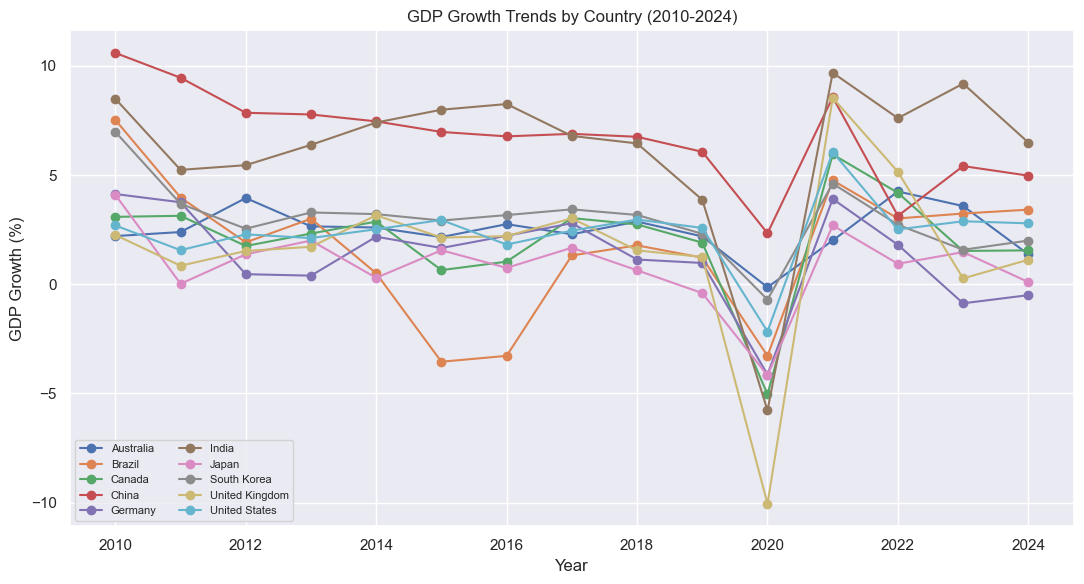

In [29]:
plt.figure(figsize=(11, 6))
for country in panel["country"].unique():
    subset = panel[panel["country"] == country]
    plt.plot(subset["year"], subset["gdp_growth"], marker="o", linewidth=1.5, label=country)
plt.title("GDP Growth Trends by Country (2010-2024)")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gdp_growth_trends.png", dpi=300)
plt.show()

## 📊 10. Visualization 2: Latest GDP Growth Comparison
A horizontal bar chart comparing the most recent growth performance.

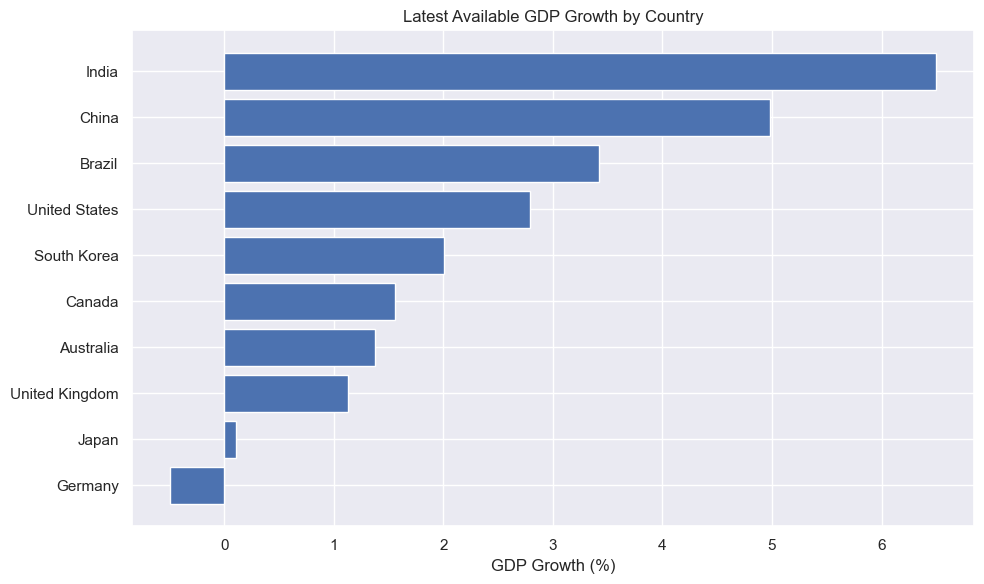

In [30]:
plt.figure(figsize=(10, 6))
ordered = latest_df.sort_values("gdp_growth", ascending=True)
plt.barh(ordered["country"], ordered["gdp_growth"])
plt.title("Latest Available GDP Growth by Country")
plt.xlabel("GDP Growth (%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "latest_gdp_growth_bar.png", dpi=300)
plt.show()

## 📉 11. Visualization 3: GDP Growth vs Inflation
A scatter plot to observe if there's an obvious relationship between inflation and growth.

> **💡 Brief Explanation:** > Typically, we will find that there is no simple, stable linear relationship between them, especially in the post-pandemic era.

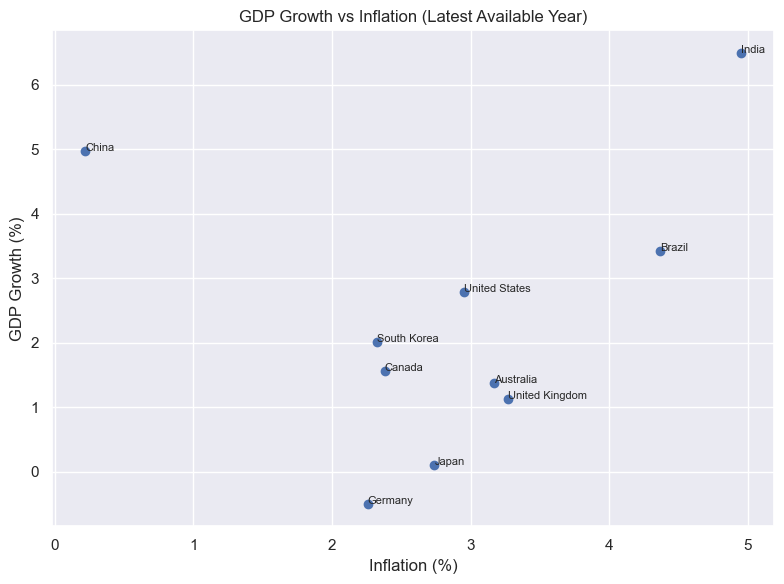

In [31]:
plot_df = latest_df.dropna(subset=["inflation", "gdp_growth"])
plt.figure(figsize=(8, 6))
plt.scatter(plot_df["inflation"], plot_df["gdp_growth"])
for _, row in plot_df.iterrows():
    plt.annotate(row["country"], (row["inflation"], row["gdp_growth"]), fontsize=8)
plt.title("GDP Growth vs Inflation (Latest Available Year)")
plt.xlabel("Inflation (%)")
plt.ylabel("GDP Growth (%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gdp_vs_inflation_scatter.png", dpi=300)
plt.show()

## 🌡️ 12. Visualization 4: Correlation Heatmap
Shows the overall correlation between the three macroeconomic indicators.

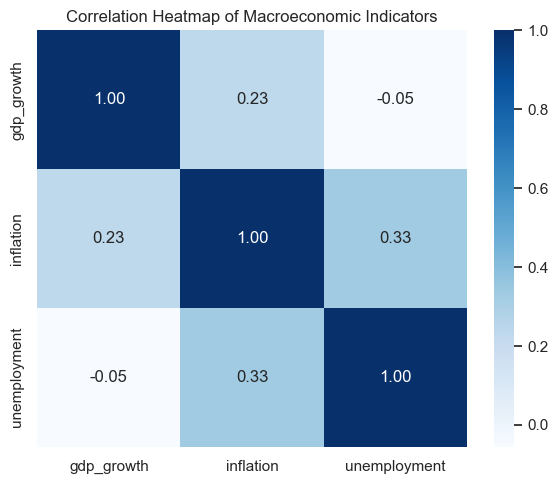

In [32]:
corr_df = panel[["gdp_growth", "inflation", "unemployment"]].corr(numeric_only=True)
plt.figure(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap of Macroeconomic Indicators")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "macro_correlation_heatmap.png", dpi=300)
plt.show()

## 📦 13. Visualization 5: Distribution & Volatility (Boxplot)
Showcases the stability and extreme scenarios of economic growth over the past 15 years.

> **💡 Brief Explanation:**
> A flatter box indicates stable economic growth (e.g., mature developed countries). A taller box or numerous outliers indicate high volatility (e.g., due to policy shifts or pandemic shocks).

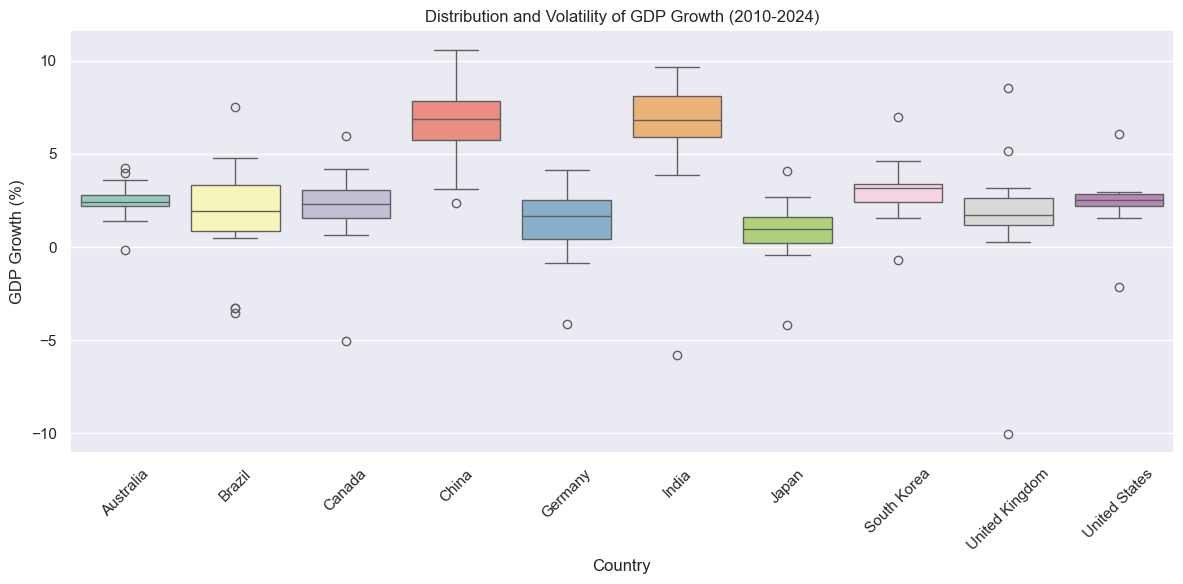

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x="country", y="gdp_growth", data=panel, 
            palette="Set3", hue="country", legend=False)
plt.title("Distribution and Volatility of GDP Growth (2010-2024)")
plt.xlabel("Country")
plt.ylabel("GDP Growth (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gdp_volatility_boxplot.png", dpi=300)
plt.show()

## ⚖️ 14. Visualization 6: Exploring Okun's Law
A regression scatter plot to see if economic growth is accompanied by a decrease in unemployment.

> **💡 Brief Explanation:**
> The red trend line visually demonstrates "Okun's Law" in macroeconomics within our dataset, suggesting an inverse relationship between unemployment and GDP growth.

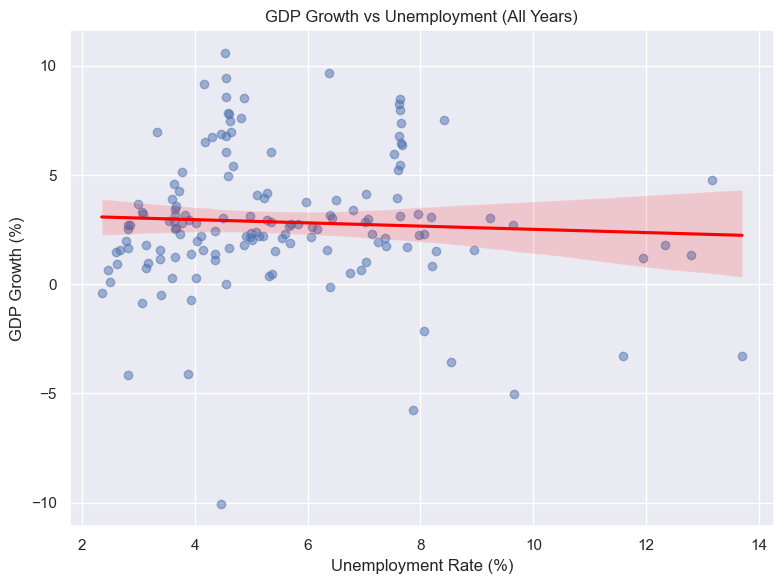

In [34]:
plt.figure(figsize=(8, 6))
plot_df_unemp = panel.dropna(subset=["unemployment", "gdp_growth"])
sns.regplot(x="unemployment", y="gdp_growth", data=plot_df_unemp, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("GDP Growth vs Unemployment (All Years)")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("GDP Growth (%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gdp_vs_unemployment_reg.png", dpi=300)
plt.show()

## 🇺🇸 15. Visualization 7: USA Macro Dynamics (Dual-Axis)
An in-depth look at the dynamic interplay between inflation and growth within a single economy.

> **💡 Brief Explanation:**
> The dual-axis chart perfectly maps the trends of two differently scaled indicators. It clearly shows periods where high inflation coincides with an economic slowdown (stagflation fears).

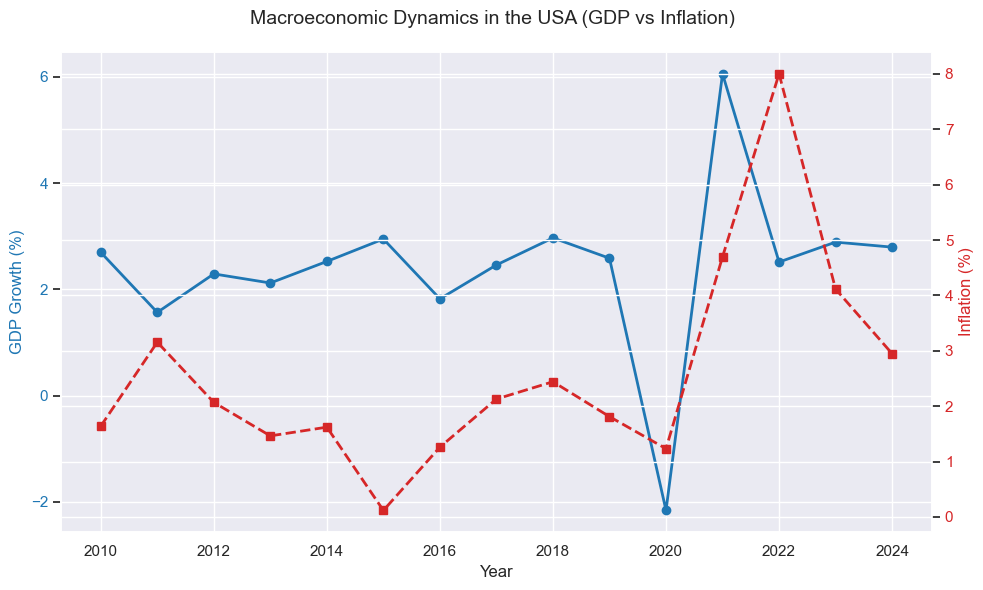

In [35]:
usa_data = panel[panel["country_code"] == "USA"].dropna(subset=["gdp_growth", "inflation"])

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP Growth (%)', color=color1)
ax1.plot(usa_data['year'], usa_data['gdp_growth'], color=color1, marker='o', linewidth=2, label='GDP Growth')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx() 
color2 = 'tab:red'
ax2.set_ylabel('Inflation (%)', color=color2)
ax2.plot(usa_data['year'], usa_data['inflation'], color=color2, marker='s', linestyle='--', linewidth=2, label='Inflation')
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle("Macroeconomic Dynamics in the USA (GDP vs Inflation)", fontsize=14)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "usa_macro_dynamics.png", dpi=300)
plt.show()

## 🤖 16. Basic Modeling: Linear Regression
Using `inflation` and `unemployment` to explain `GDP growth`. 
*Note: This is an exploratory analysis, not a causal inference model.*

In [36]:
model_df = panel.dropna(subset=["gdp_growth", "inflation", "unemployment"]).copy()
X = model_df[["inflation", "unemployment"]]
y = model_df["gdp_growth"]

if model_df.empty:
    raise ValueError("No complete rows are available for regression after dropping missing values.")

model = LinearRegression()
model.fit(X, y)
pred = model.predict(X)

rmse = np.sqrt(mean_squared_error(y, pred))
r2 = r2_score(y, pred)

print("Coefficient (inflation):", round(model.coef_[0], 4))
print("Coefficient (unemployment):", round(model.coef_[1], 4))
print("Intercept:", round(model.intercept_, 4))
print("R^2:", round(r2, 4))
print("RMSE:", round(rmse, 4))
print("Sample size:", len(model_df))

Coefficient (inflation): 0.3604
Coefficient (unemployment): -0.2004
Intercept: 2.8807
R^2: 0.0744
RMSE: 2.9603
Sample size: 150


## 💾 17. Export Results
Save the cleaned data and summary to the `outputs/` folder for GitHub presentation and future reference.

In [37]:
long_df.to_csv(OUTPUT_DIR / "macro_raw_long.csv", index=False)
panel.to_csv(OUTPUT_DIR / "macro_panel.csv", index=False)
latest_df.to_csv(OUTPUT_DIR / "latest_snapshot.csv", index=False)

summary_text = textwrap.dedent(f"""
Linear Regression Summary
=========================
Target variable: GDP growth
Features: inflation, unemployment

Coefficients:
- inflation: {model.coef_[0]:.4f}
- unemployment: {model.coef_[1]:.4f}
Intercept: {model.intercept_:.4f}

Model fit:
- R^2: {r2:.4f}
- RMSE: {rmse:.4f}

Sample size: {len(model_df)}
""").strip()

with open(OUTPUT_DIR / "regression_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("✅ All outputs have been saved successfully to the 'outputs/' folder.")

✅ All outputs have been saved successfully to the 'outputs/' folder.


## 📝 18. Conclusion & Limitations

### ✨ Key Findings
1. **Cross-country differences:** There are stark differences in growth performance and volatility across nations.
2. **Inflation relationship:** There is no single, stable directional relationship between inflation and growth globally.
3. **Unemployment relationship (Okun's Law):** Unemployment generally exhibits a negative correlation with growth, though not universal.
4. **Analytical implication:** A few macro indicators offer insights but are insufficient to fully explain economic growth.

### ⚠️ Limitations
- **Missing Data:** Recent years may have reporting lags.
- **Limited Scope:** Using only 3 indicators yields low explanatory power ($R^2$).
- **Methodology:** Linear regression here is exploratory and cannot determine causality.
- **Heterogeneity:** Countries differ vastly in institutions, industrial structures, and policy environments.